# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


通读文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet` 类。

实现网络的初始化、前向传播和反向传播。在本次作业中，你需要在 `cs231n/layers.py` 文件中实现各个层的功能。你可以复用之前实现的 `affine_forward`（仿射前向传播）、`affine_backward`（仿射反向传播）、`relu_forward`（ReLU前向传播）、`relu_backward`（ReLU反向传播）和 `softmax_loss`（Softmax损失函数）函数。目前无需考虑实现dropout（随机失活）或batch/layer normalization（批量/层归一化），这些功能你将在后续步骤中添加。

In [3]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt

from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [4]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

## 初始损失与梯度检查

作为合理性检查，运行以下代码来验证初始损失，并对**有无正则化**两种情况下的网络进行梯度校验。这是判断初始损失是否合理的有效方法。

进行梯度检查时，你应该会看到误差在 **1e-7 或更小** 左右。

In [5]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674471656573e-07
W2 relative error: 2.2120479295080622e-05
W3 relative error: 4.5623278736665505e-07
b1 relative error: 4.6600944653202505e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 1.1358395917166688e-08
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989247437803e-08
b1 relative error: 1.4752427965311745e-08
b2 relative error: 1.7223751746766738e-09
b3 relative error: 2.378772438198909e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.
作为另一项合理性检查，请确保你的网络能够在包含50张图像的小型数据集上**过拟合**。

首先，我们尝试一个三层网络，每个隐藏层包含100个神经元。在下面的代码单元中，调整**学习率**和**权重初始化尺度**，使模型过拟合，并在20个epoch内达到100%的训练准确率。

Running check with ws =  0.001
Running check with lr =  0.0001
(Iteration 1 / 40) loss: 2.302589
(Epoch 0 / 20) train acc: 0.040000; val_acc: 0.090000
(Epoch 1 / 20) train acc: 0.040000; val_acc: 0.090000
(Epoch 2 / 20) train acc: 0.060000; val_acc: 0.085000
(Epoch 3 / 20) train acc: 0.060000; val_acc: 0.077000
(Epoch 4 / 20) train acc: 0.080000; val_acc: 0.084000
(Epoch 5 / 20) train acc: 0.080000; val_acc: 0.085000
(Iteration 11 / 40) loss: 2.302589
(Epoch 6 / 20) train acc: 0.080000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.100000; val_acc: 0.074000
(Epoch 8 / 20) train acc: 0.100000; val_acc: 0.082000
(Epoch 9 / 20) train acc: 0.120000; val_acc: 0.081000
(Epoch 10 / 20) train acc: 0.120000; val_acc: 0.086000
(Iteration 21 / 40) loss: 2.302555
(Epoch 11 / 20) train acc: 0.120000; val_acc: 0.092000
(Epoch 12 / 20) train acc: 0.120000; val_acc: 0.089000
(Epoch 13 / 20) train acc: 0.120000; val_acc: 0.092000
(Epoch 14 / 20) train acc: 0.120000; val_acc: 0.093000
(Epoch 15 / 20) tr

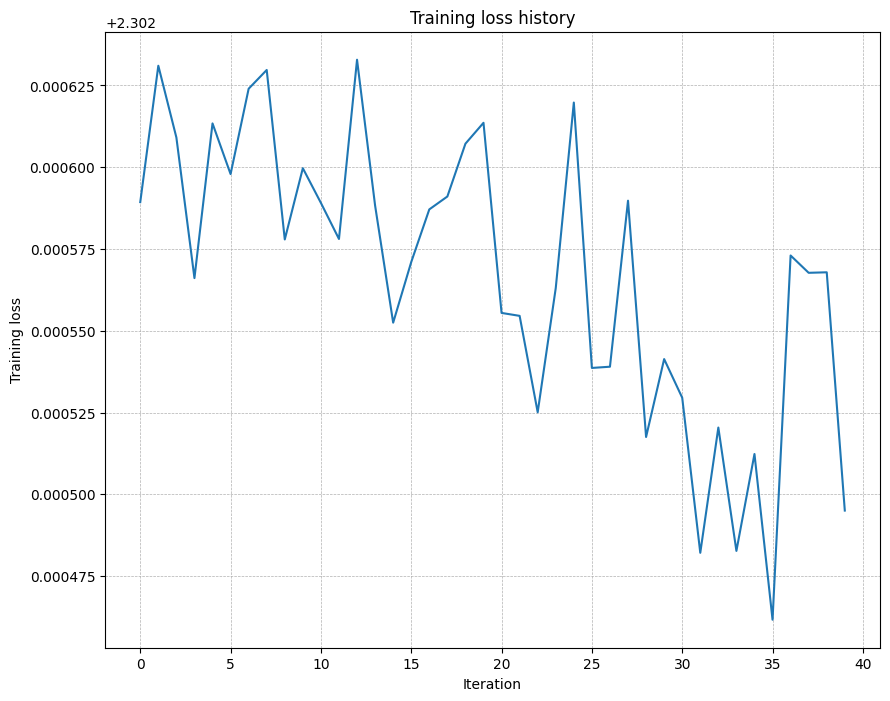

Running check with ws =  0.001
Running check with lr =  0.001
(Iteration 1 / 40) loss: 2.302579
(Epoch 0 / 20) train acc: 0.060000; val_acc: 0.097000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.103000
(Epoch 2 / 20) train acc: 0.120000; val_acc: 0.107000
(Epoch 3 / 20) train acc: 0.120000; val_acc: 0.097000
(Epoch 4 / 20) train acc: 0.120000; val_acc: 0.092000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.083000
(Iteration 11 / 40) loss: 2.302392
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.083000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.089000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.078000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.078000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.078000
(Iteration 21 / 40) loss: 2.302333
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.078000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) tra

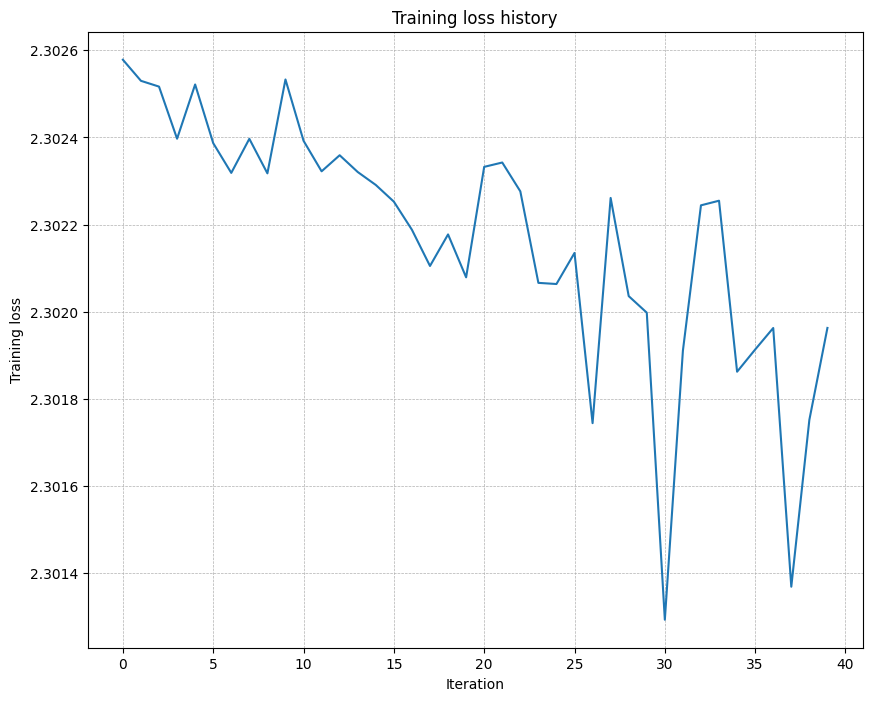

Running check with ws =  0.001
Running check with lr =  0.01
(Iteration 1 / 40) loss: 2.302531
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.121000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.092000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.080000
(Epoch 3 / 20) train acc: 0.220000; val_acc: 0.101000
(Epoch 4 / 20) train acc: 0.120000; val_acc: 0.105000
(Epoch 5 / 20) train acc: 0.180000; val_acc: 0.117000
(Iteration 11 / 40) loss: 2.301076
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.300592
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) trai

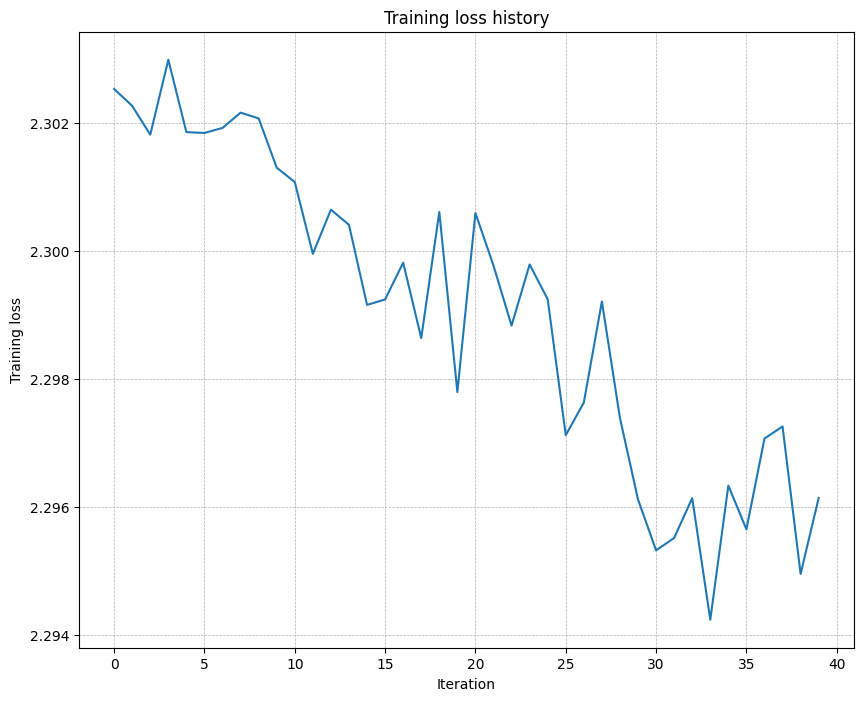

Running check with ws =  0.01
Running check with lr =  0.0001
(Iteration 1 / 40) loss: 2.356633
(Epoch 0 / 20) train acc: 0.100000; val_acc: 0.124000
(Epoch 1 / 20) train acc: 0.100000; val_acc: 0.122000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.120000
(Epoch 3 / 20) train acc: 0.100000; val_acc: 0.122000
(Epoch 4 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 5 / 20) train acc: 0.120000; val_acc: 0.120000
(Iteration 11 / 40) loss: 2.238788
(Epoch 6 / 20) train acc: 0.120000; val_acc: 0.120000
(Epoch 7 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 8 / 20) train acc: 0.120000; val_acc: 0.120000
(Epoch 9 / 20) train acc: 0.120000; val_acc: 0.121000
(Epoch 10 / 20) train acc: 0.120000; val_acc: 0.122000
(Iteration 21 / 40) loss: 2.245658
(Epoch 11 / 20) train acc: 0.140000; val_acc: 0.123000
(Epoch 12 / 20) train acc: 0.140000; val_acc: 0.126000
(Epoch 13 / 20) train acc: 0.140000; val_acc: 0.126000
(Epoch 14 / 20) train acc: 0.140000; val_acc: 0.125000
(Epoch 15 / 20) tra

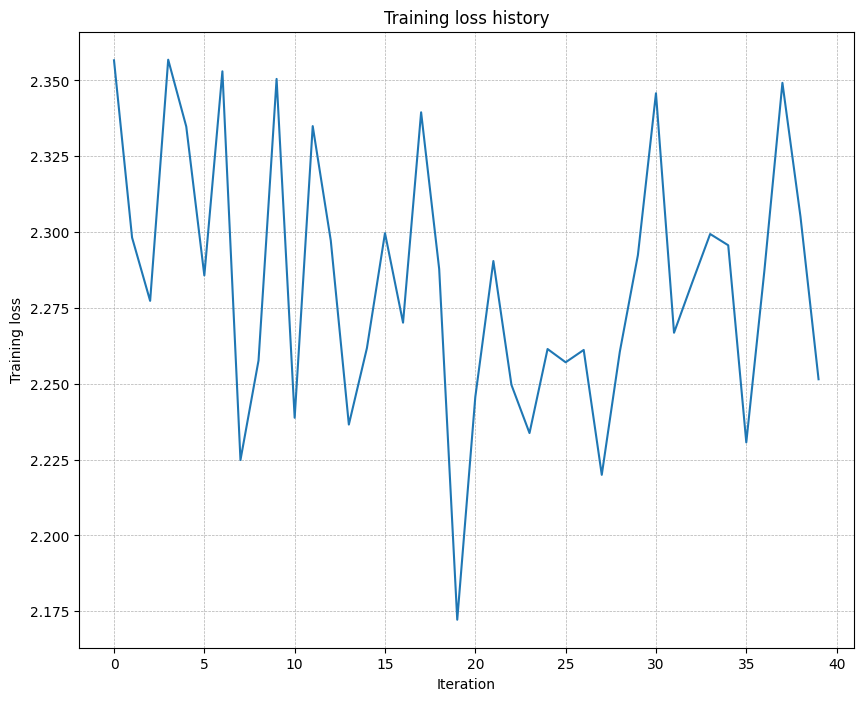

Running check with ws =  0.01
Running check with lr =  0.001
(Iteration 1 / 40) loss: 2.334081
(Epoch 0 / 20) train acc: 0.100000; val_acc: 0.103000
(Epoch 1 / 20) train acc: 0.120000; val_acc: 0.109000
(Epoch 2 / 20) train acc: 0.140000; val_acc: 0.110000
(Epoch 3 / 20) train acc: 0.240000; val_acc: 0.125000
(Epoch 4 / 20) train acc: 0.280000; val_acc: 0.134000
(Epoch 5 / 20) train acc: 0.360000; val_acc: 0.145000
(Iteration 11 / 40) loss: 2.162632
(Epoch 6 / 20) train acc: 0.380000; val_acc: 0.149000
(Epoch 7 / 20) train acc: 0.360000; val_acc: 0.154000
(Epoch 8 / 20) train acc: 0.380000; val_acc: 0.157000
(Epoch 9 / 20) train acc: 0.400000; val_acc: 0.157000
(Epoch 10 / 20) train acc: 0.340000; val_acc: 0.150000
(Iteration 21 / 40) loss: 1.960697
(Epoch 11 / 20) train acc: 0.420000; val_acc: 0.158000
(Epoch 12 / 20) train acc: 0.440000; val_acc: 0.168000
(Epoch 13 / 20) train acc: 0.500000; val_acc: 0.160000
(Epoch 14 / 20) train acc: 0.500000; val_acc: 0.165000
(Epoch 15 / 20) trai

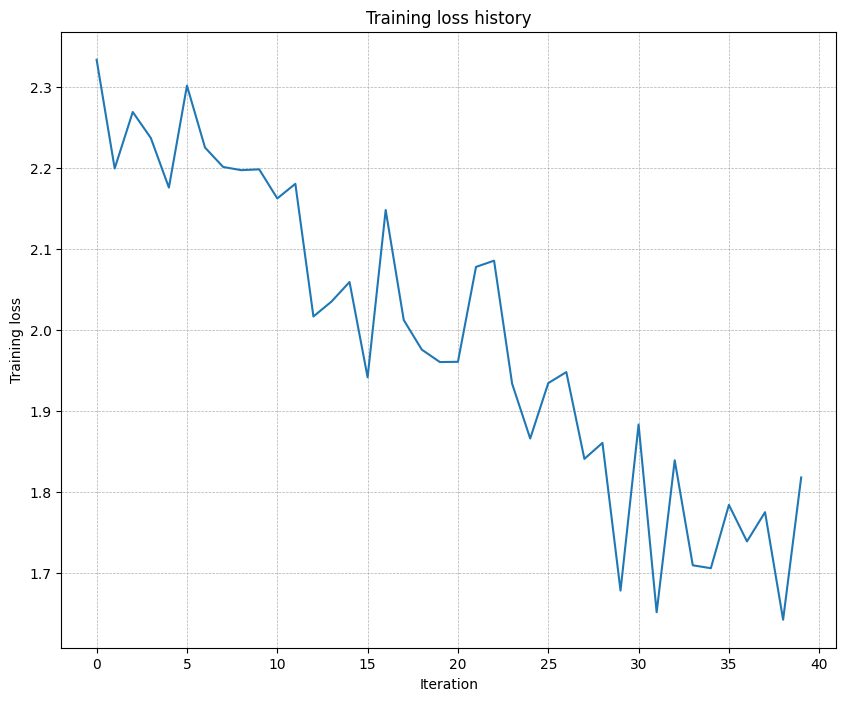

Running check with ws =  0.01
Running check with lr =  0.01
(Iteration 1 / 40) loss: 2.277837
(Epoch 0 / 20) train acc: 0.300000; val_acc: 0.131000
(Epoch 1 / 20) train acc: 0.340000; val_acc: 0.127000
(Epoch 2 / 20) train acc: 0.440000; val_acc: 0.133000
(Epoch 3 / 20) train acc: 0.640000; val_acc: 0.174000
(Epoch 4 / 20) train acc: 0.480000; val_acc: 0.167000
(Epoch 5 / 20) train acc: 0.720000; val_acc: 0.161000
(Iteration 11 / 40) loss: 1.110195
(Epoch 6 / 20) train acc: 0.760000; val_acc: 0.176000
(Epoch 7 / 20) train acc: 0.820000; val_acc: 0.158000
(Epoch 8 / 20) train acc: 0.780000; val_acc: 0.205000
(Epoch 9 / 20) train acc: 0.880000; val_acc: 0.173000
(Epoch 10 / 20) train acc: 0.940000; val_acc: 0.181000
(Iteration 21 / 40) loss: 0.403489
(Epoch 11 / 20) train acc: 0.840000; val_acc: 0.162000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.175000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.189000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.181000
(Epoch 15 / 20) train

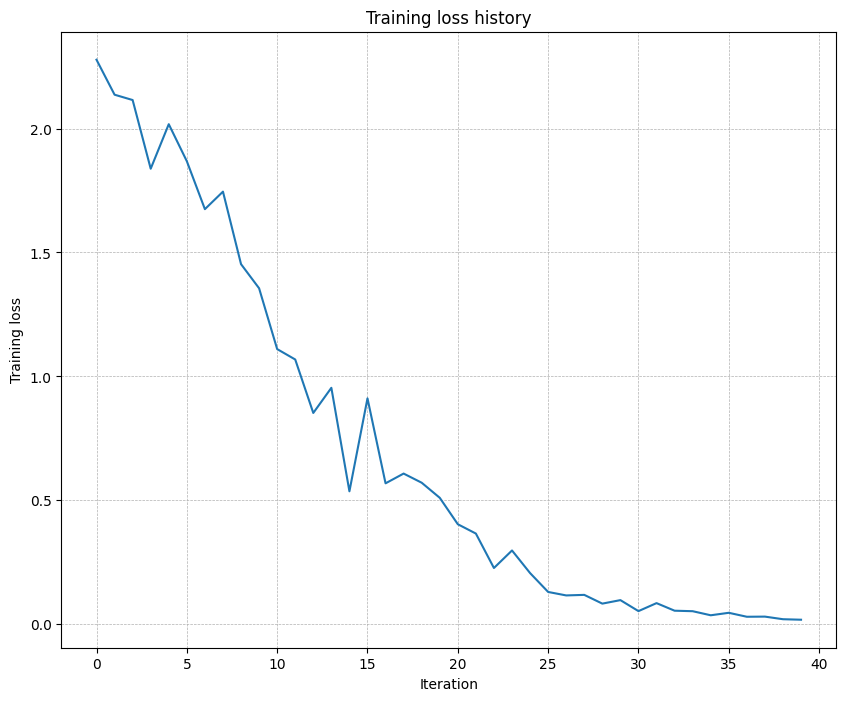

Running check with ws =  0.1
Running check with lr =  0.0001
(Iteration 1 / 40) loss: inf
(Epoch 0 / 20) train acc: 0.080000; val_acc: 0.083000
(Epoch 1 / 20) train acc: 0.140000; val_acc: 0.086000
(Epoch 2 / 20) train acc: 0.140000; val_acc: 0.110000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.119000
(Epoch 4 / 20) train acc: 0.320000; val_acc: 0.107000
(Epoch 5 / 20) train acc: 0.400000; val_acc: 0.116000
(Iteration 11 / 40) loss: 34.253248
(Epoch 6 / 20) train acc: 0.500000; val_acc: 0.109000
(Epoch 7 / 20) train acc: 0.560000; val_acc: 0.113000
(Epoch 8 / 20) train acc: 0.700000; val_acc: 0.103000
(Epoch 9 / 20) train acc: 0.700000; val_acc: 0.113000
(Epoch 10 / 20) train acc: 0.680000; val_acc: 0.112000
(Iteration 21 / 40) loss: 14.285032
(Epoch 11 / 20) train acc: 0.740000; val_acc: 0.119000
(Epoch 12 / 20) train acc: 0.840000; val_acc: 0.123000
(Epoch 13 / 20) train acc: 0.820000; val_acc: 0.116000
(Epoch 14 / 20) train acc: 0.820000; val_acc: 0.121000
(Epoch 15 / 20) train a

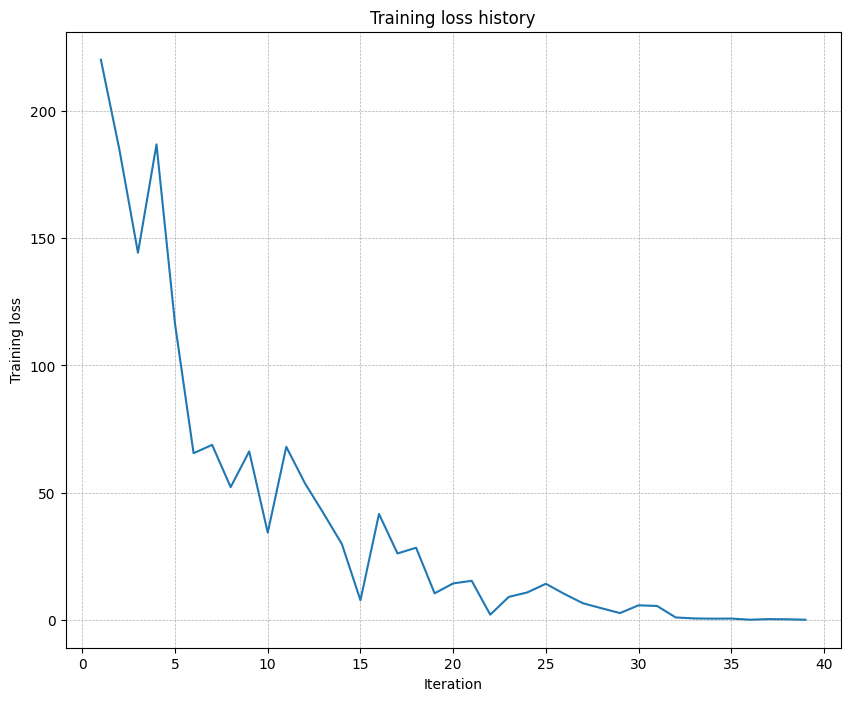

Running check with ws =  0.1
Running check with lr =  0.001
(Iteration 1 / 40) loss: 161.172943
(Epoch 0 / 20) train acc: 0.280000; val_acc: 0.153000
(Epoch 1 / 20) train acc: 0.180000; val_acc: 0.102000
(Epoch 2 / 20) train acc: 0.580000; val_acc: 0.134000
(Epoch 3 / 20) train acc: 0.520000; val_acc: 0.136000
(Epoch 4 / 20) train acc: 0.820000; val_acc: 0.152000
(Epoch 5 / 20) train acc: 0.820000; val_acc: 0.159000
(Iteration 11 / 40) loss: 0.338903
(Epoch 6 / 20) train acc: 0.880000; val_acc: 0.152000
(Epoch 7 / 20) train acc: 0.940000; val_acc: 0.157000
(Epoch 8 / 20) train acc: 0.960000; val_acc: 0.144000
(Epoch 9 / 20) train acc: 0.960000; val_acc: 0.148000
(Epoch 10 / 20) train acc: 1.000000; val_acc: 0.156000
(Iteration 21 / 40) loss: 0.000000
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.156000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.156000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.156000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.156000
(Epoch 15 / 20) tra

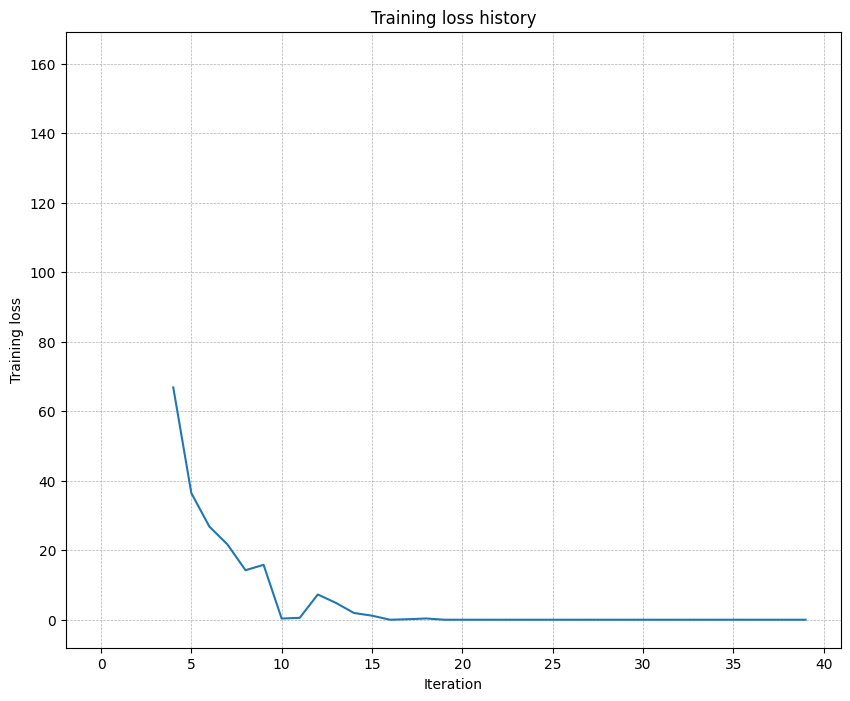

Running check with ws =  0.1
Running check with lr =  0.01
(Iteration 1 / 40) loss: 209.932663
(Epoch 0 / 20) train acc: 0.120000; val_acc: 0.105000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.083000
(Epoch 3 / 20) train acc: 0.100000; val_acc: 0.101000
(Epoch 4 / 20) train acc: 0.100000; val_acc: 0.078000
(Epoch 5 / 20) train acc: 0.120000; val_acc: 0.105000
(Iteration 11 / 40) loss: inf
(Epoch 6 / 20) train acc: 0.060000; val_acc: 0.097000
(Epoch 7 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 8 / 20) train acc: 0.080000; val_acc: 0.087000


/Users/wangzihan/Desktop/Homework/cs231n/assignment1/cs231n/layers.py:809: RuntimeWarning: invalid value encountered in subtract
  shift_scores = x - np.max(x,axis=1,keepdims = True)


(Epoch 9 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 10 / 20) train acc: 0.080000; val_acc: 0.087000
(Iteration 21 / 40) loss: nan
(Epoch 11 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 12 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 13 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 14 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 15 / 20) train acc: 0.080000; val_acc: 0.087000
(Iteration 31 / 40) loss: nan
(Epoch 16 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 17 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 18 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 19 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 20 / 20) train acc: 0.080000; val_acc: 0.087000


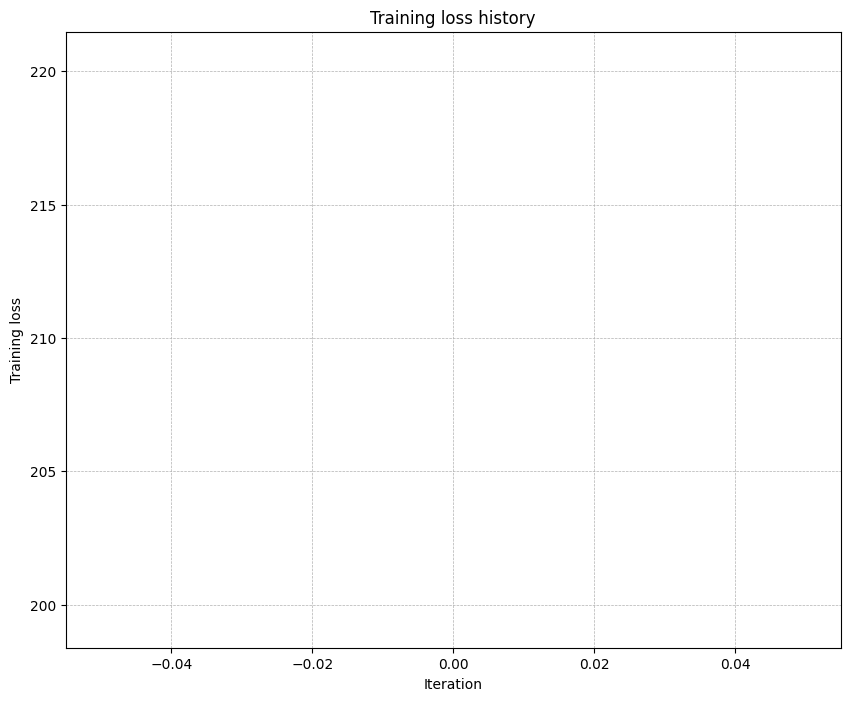

In [17]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scales =[1e-3, 1e-2, 1e-1]
learning_rates = [1e-4, 1e-3, 1e-2]


for ws in weight_scales:
    for lr in learning_rates:
        print("Running check with ws = ", ws)
        print("Running check with lr = ", lr)
        model = FullyConnectedNet(
        [100, 100],
        weight_scale=ws,
        dtype=np.float64
        )
        solver = Solver(
        model,
        small_data,
        print_every=10,
        num_epochs=20,
        batch_size=25,
        update_rule="sgd",
        optim_config={"learning_rate": lr},
        )
        solver.train()

        plt.plot(solver.loss_history)
        plt.title("Training loss history")
        plt.xlabel("Iteration")
        plt.ylabel("Training loss")
        plt.grid(linestyle='--', linewidth=0.5)
        plt.show()

#Running check with ws =  0.1
#Running check with lr =  0.001

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.
现在，尝试使用一个**5层网络**，每层包含100个神经元，在50个训练样本上实现**过拟合**。
你同样需要调整**学习率**和**权重初始化尺度**，但应该能够在20个epoch内达到**100%的训练准确率**。

Running check with ws =  0.001
Running check with lr =  0.0001
(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 11 / 40) loss: 2.302559
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 21 / 40) loss: 2.302542
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 15 / 20) tr

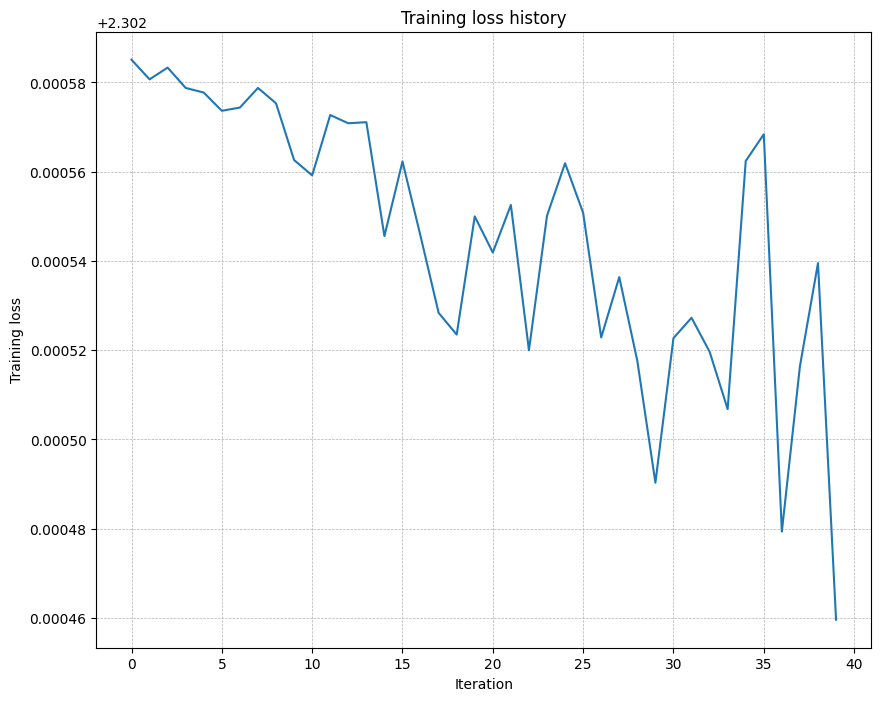

Running check with ws =  0.001
Running check with lr =  0.001
(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 5 / 20) train acc: 0.220000; val_acc: 0.079000
(Iteration 11 / 40) loss: 2.302328
(Epoch 6 / 20) train acc: 0.260000; val_acc: 0.089000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.113000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 21 / 40) loss: 2.302410
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 15 / 20) tra

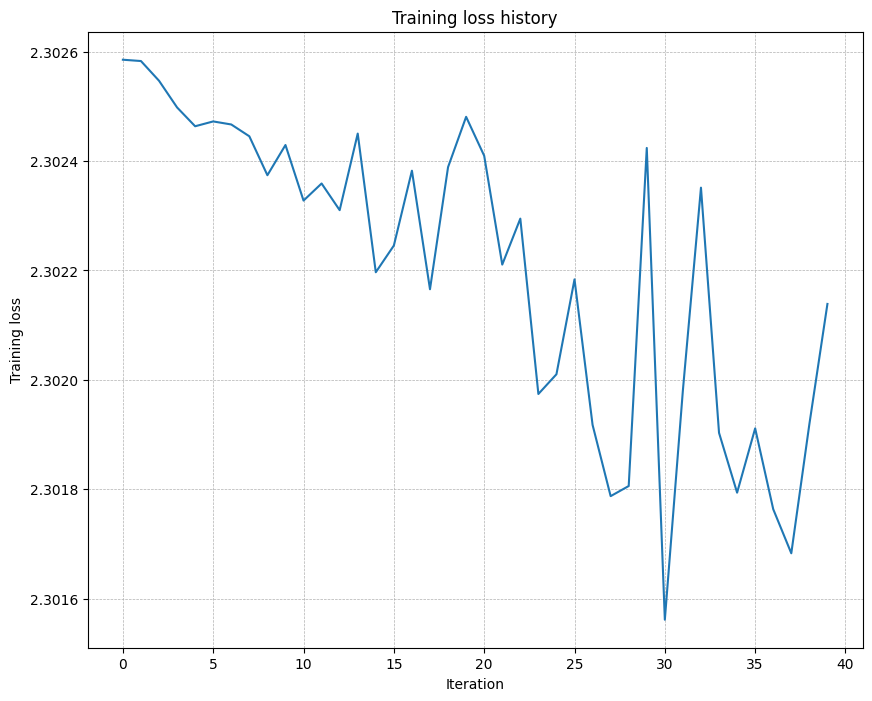

Running check with ws =  0.001
Running check with lr =  0.01
(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.100000; val_acc: 0.102000
(Epoch 1 / 20) train acc: 0.100000; val_acc: 0.102000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 11 / 40) loss: 2.300768
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.299377
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) trai

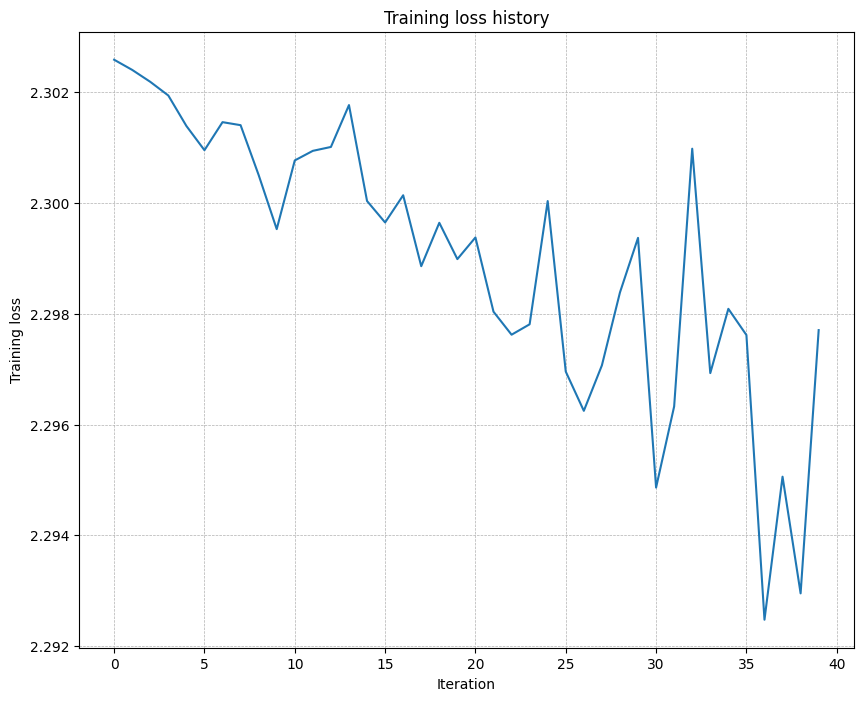

Running check with ws =  0.01
Running check with lr =  0.0001
(Iteration 1 / 40) loss: 2.303240
(Epoch 0 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 1 / 20) train acc: 0.060000; val_acc: 0.108000
(Epoch 2 / 20) train acc: 0.060000; val_acc: 0.107000
(Epoch 3 / 20) train acc: 0.060000; val_acc: 0.105000
(Epoch 4 / 20) train acc: 0.060000; val_acc: 0.106000
(Epoch 5 / 20) train acc: 0.060000; val_acc: 0.108000
(Iteration 11 / 40) loss: 2.302527
(Epoch 6 / 20) train acc: 0.080000; val_acc: 0.106000
(Epoch 7 / 20) train acc: 0.080000; val_acc: 0.106000
(Epoch 8 / 20) train acc: 0.080000; val_acc: 0.106000
(Epoch 9 / 20) train acc: 0.080000; val_acc: 0.106000
(Epoch 10 / 20) train acc: 0.080000; val_acc: 0.107000
(Iteration 21 / 40) loss: 2.302280
(Epoch 11 / 20) train acc: 0.100000; val_acc: 0.106000
(Epoch 12 / 20) train acc: 0.100000; val_acc: 0.104000
(Epoch 13 / 20) train acc: 0.100000; val_acc: 0.104000
(Epoch 14 / 20) train acc: 0.100000; val_acc: 0.100000
(Epoch 15 / 20) tra

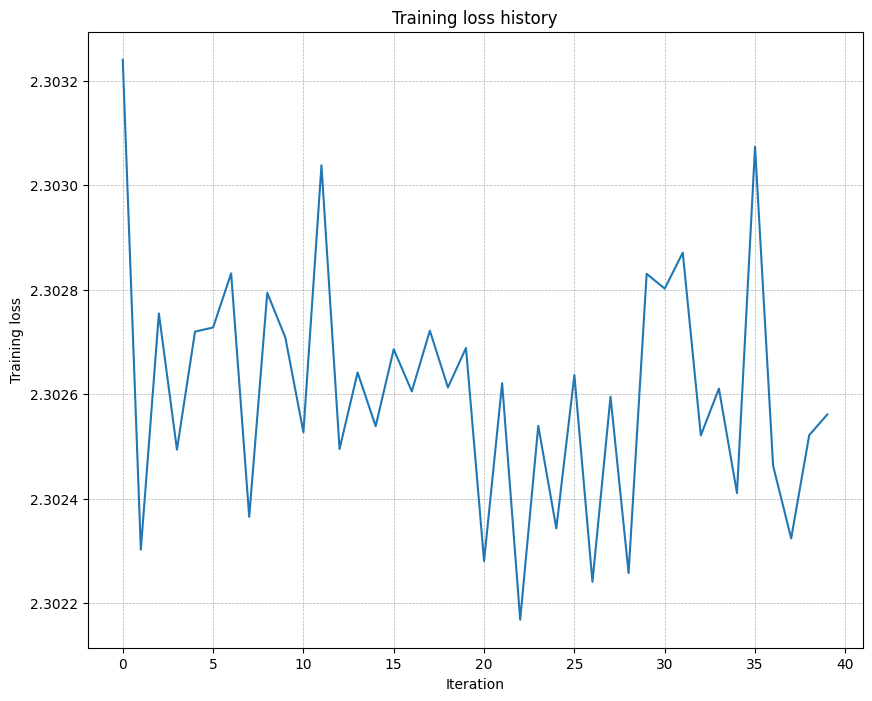

Running check with ws =  0.01
Running check with lr =  0.001
(Iteration 1 / 40) loss: 2.302535
(Epoch 0 / 20) train acc: 0.060000; val_acc: 0.096000
(Epoch 1 / 20) train acc: 0.060000; val_acc: 0.096000
(Epoch 2 / 20) train acc: 0.120000; val_acc: 0.105000
(Epoch 3 / 20) train acc: 0.120000; val_acc: 0.104000
(Epoch 4 / 20) train acc: 0.140000; val_acc: 0.104000
(Epoch 5 / 20) train acc: 0.140000; val_acc: 0.102000
(Iteration 11 / 40) loss: 2.302077
(Epoch 6 / 20) train acc: 0.140000; val_acc: 0.099000
(Epoch 7 / 20) train acc: 0.140000; val_acc: 0.099000
(Epoch 8 / 20) train acc: 0.140000; val_acc: 0.104000
(Epoch 9 / 20) train acc: 0.120000; val_acc: 0.105000
(Epoch 10 / 20) train acc: 0.120000; val_acc: 0.101000
(Iteration 21 / 40) loss: 2.302496
(Epoch 11 / 20) train acc: 0.140000; val_acc: 0.104000
(Epoch 12 / 20) train acc: 0.120000; val_acc: 0.102000
(Epoch 13 / 20) train acc: 0.140000; val_acc: 0.096000
(Epoch 14 / 20) train acc: 0.140000; val_acc: 0.096000
(Epoch 15 / 20) trai

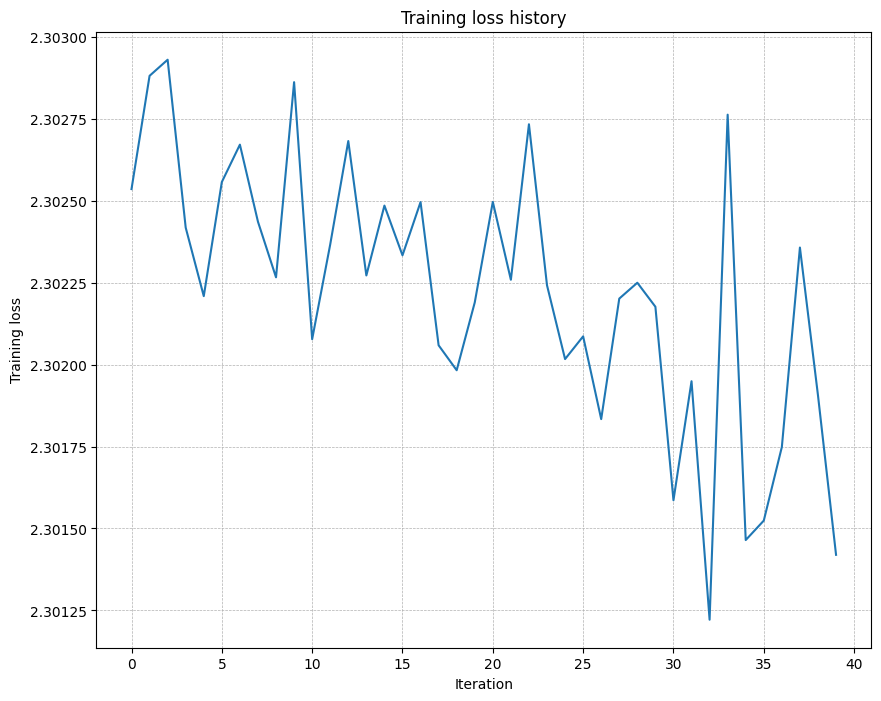

Running check with ws =  0.01
Running check with lr =  0.01
(Iteration 1 / 40) loss: 2.302578
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.114000
(Epoch 1 / 20) train acc: 0.140000; val_acc: 0.110000
(Epoch 2 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 3 / 20) train acc: 0.180000; val_acc: 0.096000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.083000
(Iteration 11 / 40) loss: 2.301131
(Epoch 6 / 20) train acc: 0.140000; val_acc: 0.108000
(Epoch 7 / 20) train acc: 0.120000; val_acc: 0.093000
(Epoch 8 / 20) train acc: 0.120000; val_acc: 0.104000
(Epoch 9 / 20) train acc: 0.120000; val_acc: 0.102000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.298725
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) train

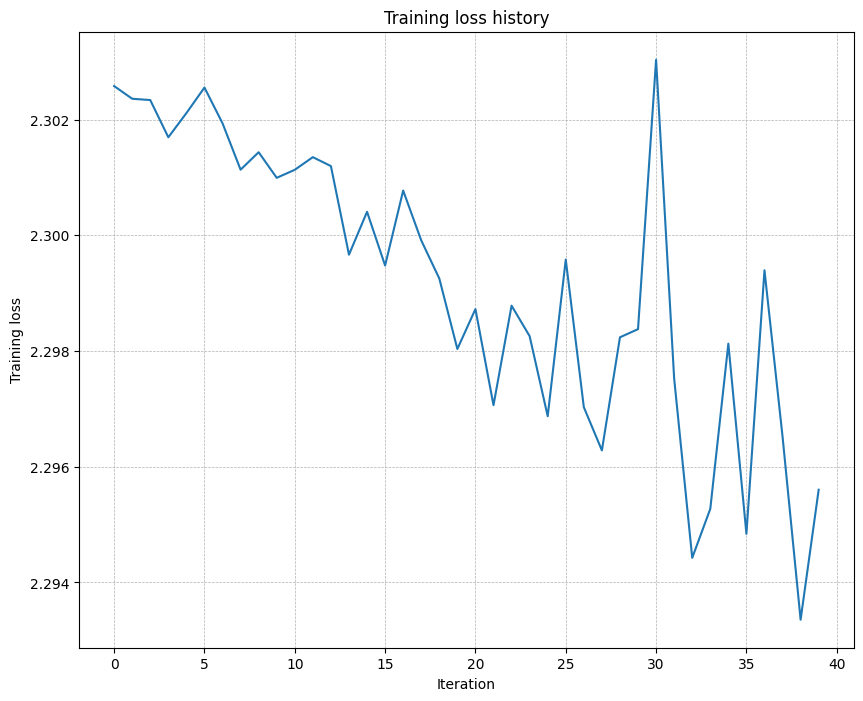

Running check with ws =  0.1
Running check with lr =  0.0001
(Iteration 1 / 40) loss: 262.584694
(Epoch 0 / 20) train acc: 0.120000; val_acc: 0.121000
(Epoch 1 / 20) train acc: 0.100000; val_acc: 0.122000
(Epoch 2 / 20) train acc: 0.140000; val_acc: 0.130000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.113000
(Epoch 4 / 20) train acc: 0.300000; val_acc: 0.109000
(Epoch 5 / 20) train acc: 0.380000; val_acc: 0.119000
(Iteration 11 / 40) loss: 12.873593
(Epoch 6 / 20) train acc: 0.480000; val_acc: 0.117000
(Epoch 7 / 20) train acc: 0.560000; val_acc: 0.126000
(Epoch 8 / 20) train acc: 0.560000; val_acc: 0.127000
(Epoch 9 / 20) train acc: 0.660000; val_acc: 0.117000
(Epoch 10 / 20) train acc: 0.720000; val_acc: 0.128000
(Iteration 21 / 40) loss: 5.693933
(Epoch 11 / 20) train acc: 0.720000; val_acc: 0.128000
(Epoch 12 / 20) train acc: 0.820000; val_acc: 0.124000
(Epoch 13 / 20) train acc: 0.880000; val_acc: 0.126000
(Epoch 14 / 20) train acc: 0.860000; val_acc: 0.123000
(Epoch 15 / 20) t

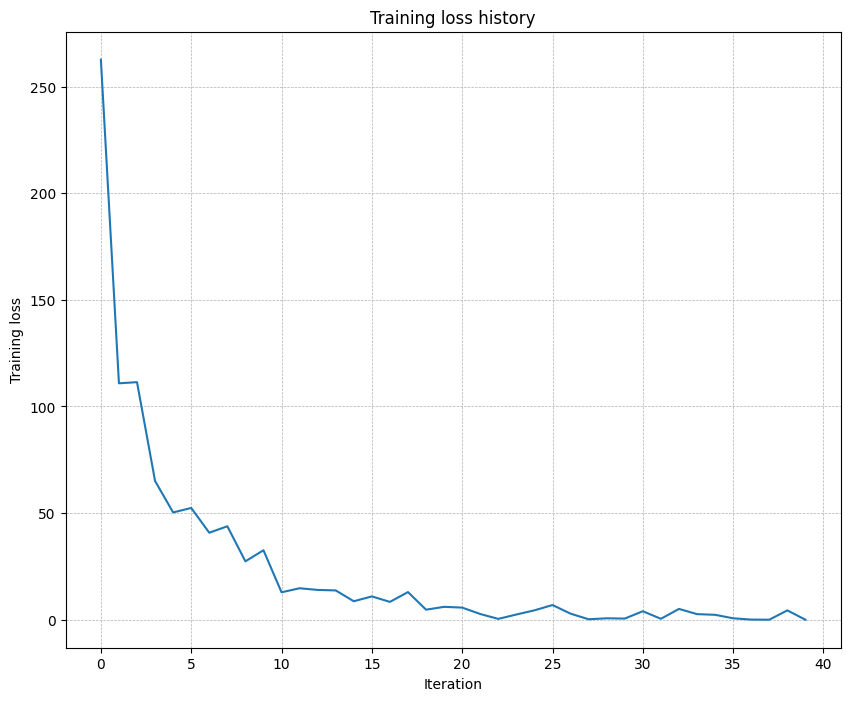

Running check with ws =  0.1
Running check with lr =  0.001
(Iteration 1 / 40) loss: 109.988723
(Epoch 0 / 20) train acc: 0.040000; val_acc: 0.108000
(Epoch 1 / 20) train acc: 0.280000; val_acc: 0.127000
(Epoch 2 / 20) train acc: 0.440000; val_acc: 0.133000
(Epoch 3 / 20) train acc: 0.540000; val_acc: 0.116000
(Epoch 4 / 20) train acc: 0.640000; val_acc: 0.120000
(Epoch 5 / 20) train acc: 0.860000; val_acc: 0.116000
(Iteration 11 / 40) loss: 1.486865
(Epoch 6 / 20) train acc: 0.920000; val_acc: 0.132000
(Epoch 7 / 20) train acc: 0.960000; val_acc: 0.125000
(Epoch 8 / 20) train acc: 1.000000; val_acc: 0.131000
(Epoch 9 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 10 / 20) train acc: 1.000000; val_acc: 0.130000
(Iteration 21 / 40) loss: 0.000340
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 15 / 20) tra

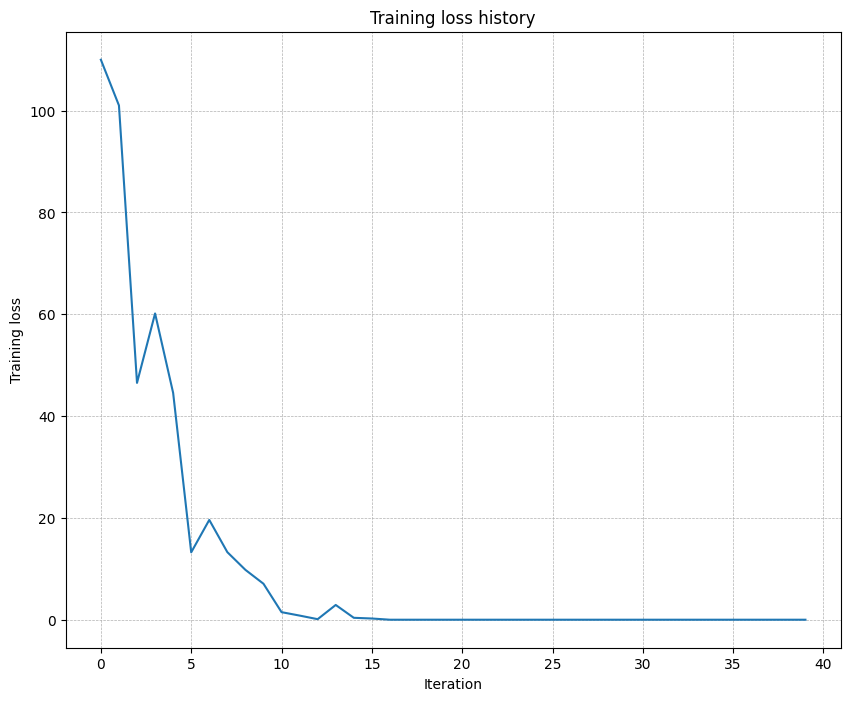

Running check with ws =  0.1
Running check with lr =  0.01
(Iteration 1 / 40) loss: 89.395936
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.112000
(Epoch 1 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.078000
(Epoch 3 / 20) train acc: 0.100000; val_acc: 0.107000
(Epoch 4 / 20) train acc: 0.080000; val_acc: 0.088000
(Epoch 5 / 20) train acc: 0.080000; val_acc: 0.087000
(Iteration 11 / 40) loss: nan
(Epoch 6 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 7 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 8 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 9 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 10 / 20) train acc: 0.080000; val_acc: 0.087000
(Iteration 21 / 40) loss: nan
(Epoch 11 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 12 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 13 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 14 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 15 / 20) train acc: 0.08

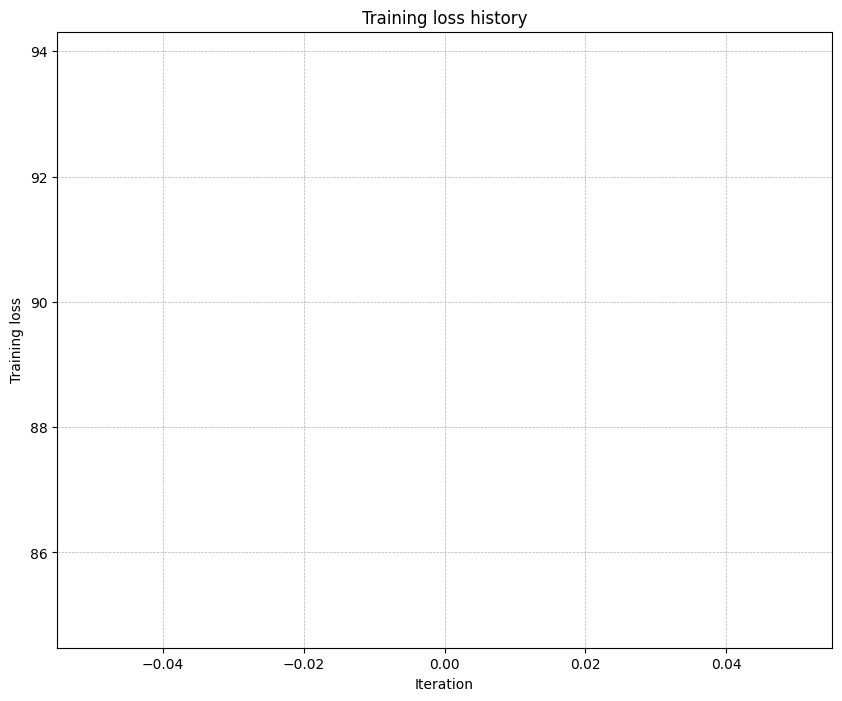

In [19]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rates = [1e-4, 1e-3, 1e-2]
weight_scales = [1e-3, 1e-2, 1e-1]

for ws in weight_scales:
    for lr in learning_rates:
        print("Running check with ws = ", ws)
        print("Running check with lr = ", lr)


        model = FullyConnectedNet(
            [100, 100, 100, 100],
            weight_scale=ws,
            dtype=np.float64
        )
        solver = Solver(
            model,
            small_data,
            print_every=10,
            num_epochs=20,
            batch_size=25,
            update_rule='sgd',
            optim_config={'learning_rate': lr},
        )
        solver.train()

        plt.plot(solver.loss_history)
        plt.title('Training loss history')
        plt.xlabel('Iteration')
        plt.ylabel('Training loss')
        plt.grid(linestyle='--', linewidth=0.5)
        plt.show()

## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
[FILL THIS IN]
## 内嵌问题 1：
你是否注意到训练三层网络与五层网络在难度上的区别？特别是根据你的实验经验，哪种网络对**初始化尺度**更敏感？你认为原因是什么？

## 回答：
[在此填写]



# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.
# 更新规则
到目前为止，我们一直使用普通随机梯度下降（SGD）作为更新规则。更复杂的更新规则可以让深度网络的训练变得更容易。我们将实现几种最常用的更新规则，并将它们与普通SGD进行对比。

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.
## 随机梯度下降 + 动量（SGD+Momentum）
带动量的随机梯度下降（SGD+Momentum）是一种应用广泛的更新规则，相比普通随机梯度下降（vanilla SGD），它通常能让深度网络更快收敛。更多相关信息可参考 http://cs231n.github.io/neural-networks-3/#sgd 中的 “动量更新（Momentum Update）” 章节。
打开文件 cs231n/optim.py，阅读文件顶部的文档说明，确保你理解对应的 API 接口。在 sgd_momentum 函数中实现 SGD + 动量的更新规则，然后运行以下代码验证你的实现是否正确。验证通过的话，你应该会看到误差值小于 1e-8（10 的负 8 次方）。

In [21]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 200) loss: 2.360400
(Epoch 0 / 5) train acc: 0.134000; val_acc: 0.123000
(Iteration 11 / 200) loss: 2.264256
(Iteration 21 / 200) loss: 2.215070
(Iteration 31 / 200) loss: 2.056387
(Epoch 1 / 5) train acc: 0.249000; val_acc: 0.222000
(Iteration 41 / 200) loss: 2.164824
(Iteration 51 / 200) loss: 2.120794
(Iteration 61 / 200) loss: 2.075793
(Iteration 71 / 200) loss: 2.038223
(Epoch 2 / 5) train acc: 0.298000; val_acc: 0.249000
(Iteration 81 / 200) loss: 2.057542
(Iteration 91 / 200) loss: 1.868909
(Iteration 101 / 200) loss: 1.781844
(Iteration 111 / 200) loss: 1.844989
(Epoch 3 / 5) train acc: 0.310000; val_acc: 0.264000
(Iteration 121 / 200) loss: 1.858892
(Iteration 131 / 200) loss: 1.967141
(Iteration 141 / 200) loss: 1.906547
(Iteration 151 / 200) loss: 1.841442
(Epoch 4 / 5) train acc: 0.377000; val_acc: 0.284000
(Iteration 161 / 200) loss: 1.829183
(Iteration 171 / 200) loss: 1.967248
(Iteration 181 / 200) loss: 1.846941
(Iteration 191 / 200) los

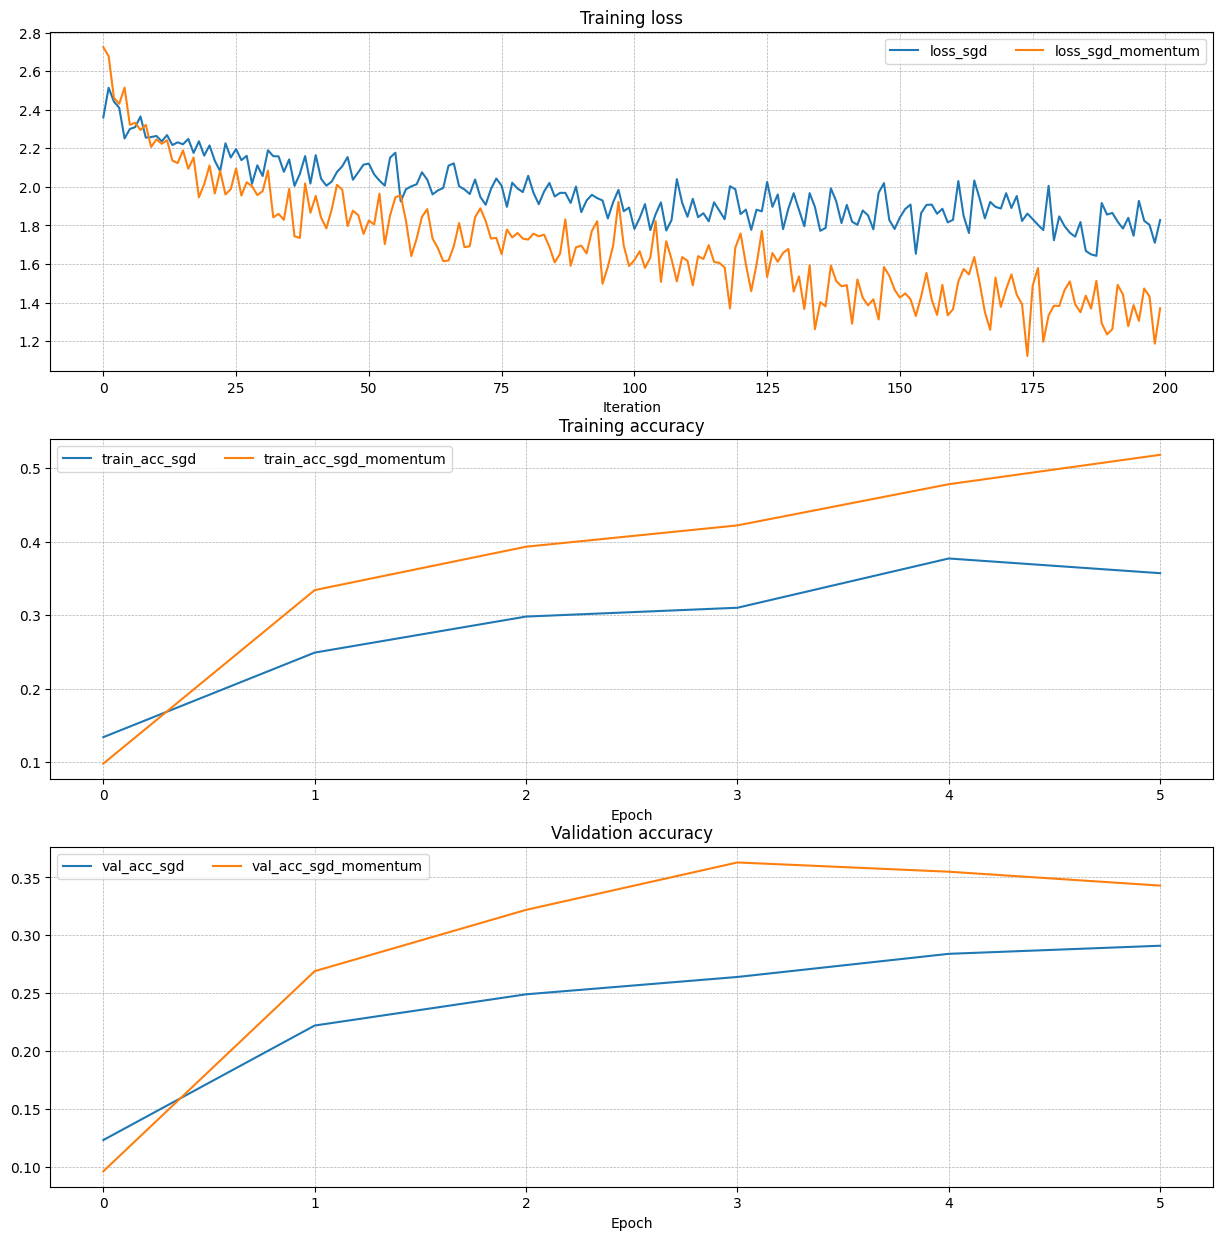

In [22]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

## RMSProp 与 Adam
RMSProp [1] 和 Adam [2] 是通过**梯度二阶矩的滑动平均**来为每个参数单独设置学习率的更新规则。

在文件 `cs231n/optim.py` 中，在 `rmsprop` 函数里实现 RMSProp 更新规则，在 `adam` 函数里实现 Adam 更新规则，并使用下面的测试代码检验你的实现。

**注意：**请实现**完整**的 Adam 更新规则（包含**偏置校正机制**），而不是课程笔记中提到的第一个简化版本。

[1] Tijmen Tieleman 和 Geoffrey Hinton.《第6.5讲：RMSProp——用梯度近期幅值的滑动平均来除以梯度》。COURSERA：机器学习神经网络课程 4（2012）。

[2] Diederik Kingma 和 Jimmy Ba.《Adam：一种随机优化方法》，ICLR 2015。

In [12]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [23]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 200) loss: 2.806716
(Epoch 0 / 5) train acc: 0.133000; val_acc: 0.113000
(Iteration 11 / 200) loss: 2.056296
(Iteration 21 / 200) loss: 1.911258
(Iteration 31 / 200) loss: 1.777557
(Epoch 1 / 5) train acc: 0.390000; val_acc: 0.318000
(Iteration 41 / 200) loss: 1.779502
(Iteration 51 / 200) loss: 1.790010
(Iteration 61 / 200) loss: 1.692805
(Iteration 71 / 200) loss: 1.685577
(Epoch 2 / 5) train acc: 0.453000; val_acc: 0.360000
(Iteration 81 / 200) loss: 1.477714
(Iteration 91 / 200) loss: 1.543523
(Iteration 101 / 200) loss: 1.341732
(Iteration 111 / 200) loss: 1.418525
(Epoch 3 / 5) train acc: 0.480000; val_acc: 0.362000
(Iteration 121 / 200) loss: 1.566800
(Iteration 131 / 200) loss: 1.199684
(Iteration 141 / 200) loss: 1.630113
(Iteration 151 / 200) loss: 1.469316
(Epoch 4 / 5) train acc: 0.580000; val_acc: 0.377000
(Iteration 161 / 200) loss: 1.059085
(Iteration 171 / 200) loss: 1.254942
(Iteration 181 / 200) loss: 1.198314
(Iteration 191 / 200) lo

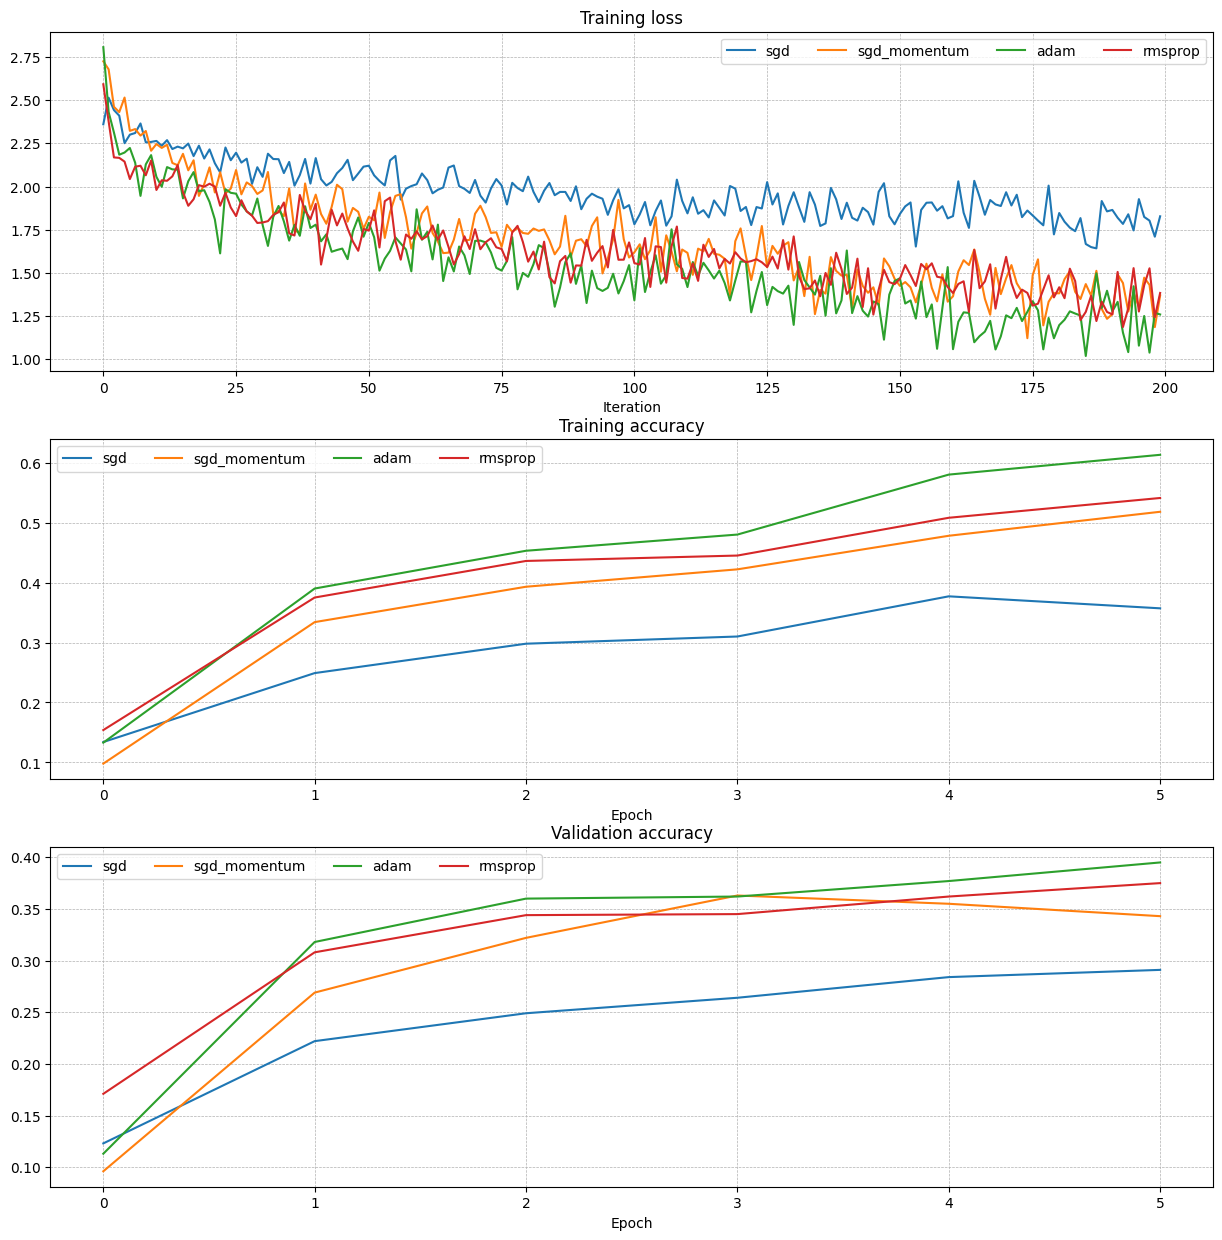

In [24]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:
[FILL THIS IN]

## 内嵌问题 2：

AdaGrad 和 Adam 类似，也是一种**逐参数**优化方法，它使用如下更新规则：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 发现，当他用 AdaGrad 训练网络时，**参数更新量变得非常小**，网络学习得很慢。
根据你对 AdaGrad 更新规则的理解，你认为为什么更新会变得很小？Adam 会出现同样的问题吗？

## 答案：
[在此填写]




# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.

# 训练一个优秀的模型！
在 CIFAR-10 数据集上训练你能实现的**最佳全连接模型**，并将表现最好的模型存入变量 `best_model`。我们要求你使用全连接网络，在验证集上至少达到 **50%** 的准确率。

如果你调参得当，准确率是**有可能超过 55%** 的，但这一部分不做强制要求，也不会为此额外加分。在下一次作业中，我们会让你在 CIFAR-10 上训练尽可能优秀的卷积网络，我们更希望你把精力放在卷积网络上，而不是全连接网络上。

**注意：** 在下一次作业中，你会学到**批量归一化（BatchNormalization）**和**随机失活（Dropout）**等技术，这些方法能帮助你训练出效果更强的模型。

In [6]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****




import numpy as np
import matplotlib.pyplot as plt
from cs231n.data_utils import load_CIFAR10

# ===================== 1. 数据预处理（关键！） =====================
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 划分验证集
num_val = 1000
num_train = 49000
X_val = X_train[:num_val].copy()
y_val = y_train[:num_val].copy()
X_train = X_train[num_val:num_val+num_train].copy()
y_train = y_train[num_val:num_val+num_train].copy()

# ✅ 减去训练集均值
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

data = {
    'X_train': X_train,
    'y_train': y_train,
    'X_val': X_val,
    'y_val': y_val,
    'X_test': X_test,
    'y_test': y_test
}

# ===================== 2. 初始化变量 =====================
best_model = None
best_val_acc = 0.0
solvers = {}
param_combinations = []

# ===================== 3. 更精细的超参数搜索 =====================
# 调整后的超参数范围
learning_rates = [1e-3, 2e-3]
weight_scales = [1e-2]
regs = [5e-5, 1e-4]
hidden_dims = [300, 300]
num_epochs = 20                       # 增加训练轮数

for lr in learning_rates:
    for ws in weight_scales:
        for reg in regs:
            param_key = f"lr_{lr}_ws_{ws}_reg_{reg}"
            print(f"\n===== Running: {param_key} =====")

            # 构建模型
            model = FullyConnectedNet(
                hidden_dims,
                weight_scale=ws,
                reg=reg,
                normalization="batchnorm",
                dropout_keep_ratio=0.5,
                dtype=np.float64
            )

            # 构建 Solver
            solver = Solver(
                model,
                data,
                num_epochs=num_epochs,
                batch_size=128,
                update_rule="adam",
                optim_config={"learning_rate": lr},
                verbose=True,
                print_every=200  # 减少打印频率
            )

            solver.train()

            # 保存结果
            solvers[param_key] = solver
            current_val_acc = solver.val_acc_history[-1]
            param_combinations.append({
                "key": param_key,
                "lr": lr,
                "ws": ws,
                "reg": reg,
                "val_acc": current_val_acc
            })

            # 更新最优模型
            if current_val_acc > best_val_acc:
                best_val_acc = current_val_acc
                best_model = model
                print(f"✅ New best! Val acc: {best_val_acc:.4f}")

# ===================== 4. 可视化最优模型的训练曲线 =====================
# 只画最优模型的曲线，避免混乱
best_solver_key = [p["key"] for p in param_combinations if p["val_acc"] == best_val_acc][0]
best_solver = solvers[best_solver_key]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].set_title(f'Training Loss (Best: {best_solver_key})')
axes[0].plot(best_solver.loss_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(linestyle='--')

axes[1].set_title('Accuracy')
axes[1].plot(best_solver.train_acc_history, label='Train')
axes[1].plot(best_solver.val_acc_history, label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(linestyle='--')

plt.tight_layout()
plt.show()

# ===================== 5. 打印总结 =====================
print("\n===== 训练总结 =====")
print(f"最优验证精度: {best_val_acc:.4f}")
best_param = [p for p in param_combinations if p["val_acc"] == best_val_acc][0]
print(f"最优参数: lr={best_param['lr']}, ws={best_param['ws']}, reg={best_param['reg']}")
################################################################################
#                              END OF YOUR CODE                                #
################################################################################


===== Running: lr_0.001_ws_0.01_reg_5e-05 =====
(Iteration 1 / 7640) loss: 2.315284
(Epoch 0 / 20) train acc: 0.153000; val_acc: 0.164000
(Iteration 201 / 7640) loss: 1.668801
(Epoch 1 / 20) train acc: 0.437000; val_acc: 0.426000
(Iteration 401 / 7640) loss: 1.467567
(Iteration 601 / 7640) loss: 1.644592
(Epoch 2 / 20) train acc: 0.515000; val_acc: 0.467000
(Iteration 801 / 7640) loss: 1.571771
(Iteration 1001 / 7640) loss: 1.461696
(Epoch 3 / 20) train acc: 0.540000; val_acc: 0.493000
(Iteration 1201 / 7640) loss: 1.612751
(Iteration 1401 / 7640) loss: 1.503041
(Epoch 4 / 20) train acc: 0.538000; val_acc: 0.479000
(Iteration 1601 / 7640) loss: 1.374292
(Iteration 1801 / 7640) loss: 1.286921
(Epoch 5 / 20) train acc: 0.530000; val_acc: 0.503000
(Iteration 2001 / 7640) loss: 1.606551
(Iteration 2201 / 7640) loss: 1.431398
(Epoch 6 / 20) train acc: 0.567000; val_acc: 0.519000
(Iteration 2401 / 7640) loss: 1.421770
(Iteration 2601 / 7640) loss: 1.488856
(Epoch 7 / 20) train acc: 0.566000

KeyboardInterrupt: 

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.

In [30]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.407
Test set accuracy:  0.4066
